## Importing Libraries and Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler

import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Dataset/chronickidneydisease.csv')
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


# Data Cleaning

### Initial Information About the Dataframe

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [4]:
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [5]:
df.shape

(400, 26)

In [6]:
df.columns.tolist()

['id',
 'age',
 'bp',
 'sg',
 'al',
 'su',
 'rbc',
 'pc',
 'pcc',
 'ba',
 'bgr',
 'bu',
 'sc',
 'sod',
 'pot',
 'hemo',
 'pcv',
 'wc',
 'rc',
 'htn',
 'dm',
 'cad',
 'appet',
 'pe',
 'ane',
 'classification']

### Creating Copy of df For Further Operations

In [7]:
df_clean = df.copy()

## Cleaning Non-Numerical columns

In [8]:
non_numerical_columns = df.select_dtypes(exclude=['number']).columns.tolist()
for column in non_numerical_columns:
    print(f"Column: {column}\n")
    print(f"Unique Values: {df[column].unique()}\n")
    print(f"Value Counts:\n {df[column].value_counts()}\n")
    print(f"Missing Values: {df[column].isnull().sum()}\n")
    print(f"Description:\n {df[column].describe()}\n")
    print("--------------------------------\n")

Column: rbc

Unique Values: [nan 'normal' 'abnormal']

Value Counts:
 rbc
normal      201
abnormal     47
Name: count, dtype: int64

Missing Values: 152

Description:
 count        248
unique         2
top       normal
freq         201
Name: rbc, dtype: object

--------------------------------

Column: pc

Unique Values: ['normal' 'abnormal' nan]

Value Counts:
 pc
normal      259
abnormal     76
Name: count, dtype: int64

Missing Values: 65

Description:
 count        335
unique         2
top       normal
freq         259
Name: pc, dtype: object

--------------------------------

Column: pcc

Unique Values: ['notpresent' 'present' nan]

Value Counts:
 pcc
notpresent    354
present        42
Name: count, dtype: int64

Missing Values: 4

Description:
 count            396
unique             2
top       notpresent
freq             354
Name: pcc, dtype: object

--------------------------------

Column: ba

Unique Values: ['notpresent' 'present' nan]

Value Counts:
 ba
notpresent    374
pr

There are some numerical columns stored as objects. Rectifying those next

## Cleaning \t ' ' ? and Other Issues

In [9]:
def clean_non_numerical_column(series):
    series = series.astype(str).str.replace('\t', '')
    series = series.astype(str).str.replace(' ', '')
    series = series.replace('?', np.nan)
    series= series.replace('nan', np.nan)
    return series

In [10]:
for column in non_numerical_columns:
    df_clean[column] = clean_non_numerical_column(df_clean[column])

## Checking if all Categorical Features are Resolved

In [11]:
unclean_categorical_columns = ['classification', 'cad', 'dm']

for column in unclean_categorical_columns:
    print(f"Column: {column}")
    print(f"Unique Values: {df_clean[column].unique()}\n")
    print(f"Value Counts:\n {df_clean[column].value_counts()}\n")
    print(f"Missing Values: {df_clean[column].isnull().sum()}\n")
    print(f"Description:\n {df_clean[column].describe()}\n")
    print("--------------------------------\n")

Column: classification
Unique Values: ['ckd' 'notckd']

Value Counts:
 classification
ckd       250
notckd    150
Name: count, dtype: int64

Missing Values: 0

Description:
 count     400
unique      2
top       ckd
freq      250
Name: classification, dtype: object

--------------------------------

Column: cad
Unique Values: ['no' 'yes' nan]

Value Counts:
 cad
no     364
yes     34
Name: count, dtype: int64

Missing Values: 2

Description:
 count     398
unique      2
top        no
freq      364
Name: cad, dtype: object

--------------------------------

Column: dm
Unique Values: ['yes' 'no' nan]

Value Counts:
 dm
no     261
yes    137
Name: count, dtype: int64

Missing Values: 2

Description:
 count     398
unique      2
top        no
freq      261
Name: dm, dtype: object

--------------------------------



## Numerical Columns stored as Objects

In [12]:
numerical_columns_to_clean = ['pcv', 'wc', 'rc']
for col in numerical_columns_to_clean:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce') # Convert to numeric, coercing errors to NaN, if in string format

    # Summary
    print(f"\nColumn: {col}")
    print(f"Data type after cleaning: {df_clean[col].dtype}")
    print(f"Number of missing values: {df_clean[col].isnull().sum()}")
    print(f"Value range: {df_clean[col].min()} to {df_clean[col].max()}")
    print(f"Mean: {df_clean[col].mean():.2f}")
    print(f"Median: {df_clean[col].median():.2f}")
    print("--------------------------------")


Column: pcv
Data type after cleaning: float64
Number of missing values: 71
Value range: 9.0 to 54.0
Mean: 38.88
Median: 40.00
--------------------------------

Column: wc
Data type after cleaning: float64
Number of missing values: 106
Value range: 2200.0 to 26400.0
Mean: 8406.12
Median: 8000.00
--------------------------------

Column: rc
Data type after cleaning: float64
Number of missing values: 131
Value range: 2.1 to 8.0
Mean: 4.71
Median: 4.80
--------------------------------


## Checking Numerical Columns

In [13]:
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()

for column in numerical_columns:
    print(f"Column: {column}")
    print(f"Missing Values: {df[column].isnull().sum()}\n")
    print(f"Data Type: {df[column].dtype}\n")
    print(f"Description:\n {df[column].describe()}\n")
    print("--------------------------------\n")

Column: id
Missing Values: 0

Data Type: int64

Description:
 count    400.000000
mean     199.500000
std      115.614301
min        0.000000
25%       99.750000
50%      199.500000
75%      299.250000
max      399.000000
Name: id, dtype: float64

--------------------------------

Column: age
Missing Values: 9

Data Type: float64

Description:
 count    391.000000
mean      51.483376
std       17.169714
min        2.000000
25%       42.000000
50%       55.000000
75%       64.500000
max       90.000000
Name: age, dtype: float64

--------------------------------

Column: bp
Missing Values: 12

Data Type: float64

Description:
 count    388.000000
mean      76.469072
std       13.683637
min       50.000000
25%       70.000000
50%       80.000000
75%       80.000000
max      180.000000
Name: bp, dtype: float64

--------------------------------

Column: sg
Missing Values: 47

Data Type: float64

Description:
 count    353.000000
mean       1.017408
std        0.005717
min        1.005000
25

No issues, proceeding to handle missing values

# Missing Pattern Analysis

In [14]:
sns.set_palette("husl")   # Set the style for better visualization

## Visualizing Missing Values

In [15]:
def plot_missing_heatmap(df):
    # Calculate missing values percentage for each column
    missing_percentage = (df.isnull().sum() / len(df)) * 100

    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

    # Plot 1: Missing value heatmap
    sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=ax1)
    ax1.set_title('Missing Values Heatmap', pad=20)

    # Plot 2: Missing values percentage bar plot
    missing_percentage.sort_values(ascending=False).plot(kind='bar', ax=ax2)
    ax2.set_title('Percentage of Missing Values by Column', pad=20)
    ax2.set_ylabel('Percentage Missing')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

    # Print detailed missing value statistics
    print("\nDetailed Missing Value Statistics:")
    print("-" * 50)
    for col in df.columns:
        missing = df[col].isnull().sum()
        percentage = (missing / len(df)) * 100
        print(f"{col}:")
        print(f"  Missing values: {missing} ({percentage:.2f}%)")
        if df[col].dtype == 'object':
            print(f"  Most common value: {df[col].value_counts().index[0] if not df[col].value_counts().empty else 'N/A'}")
        else:
            print(f"  Mean: {df[col].mean():.2f}")
            print(f"  Median: {df[col].median():.2f}")
        print("-" * 50)

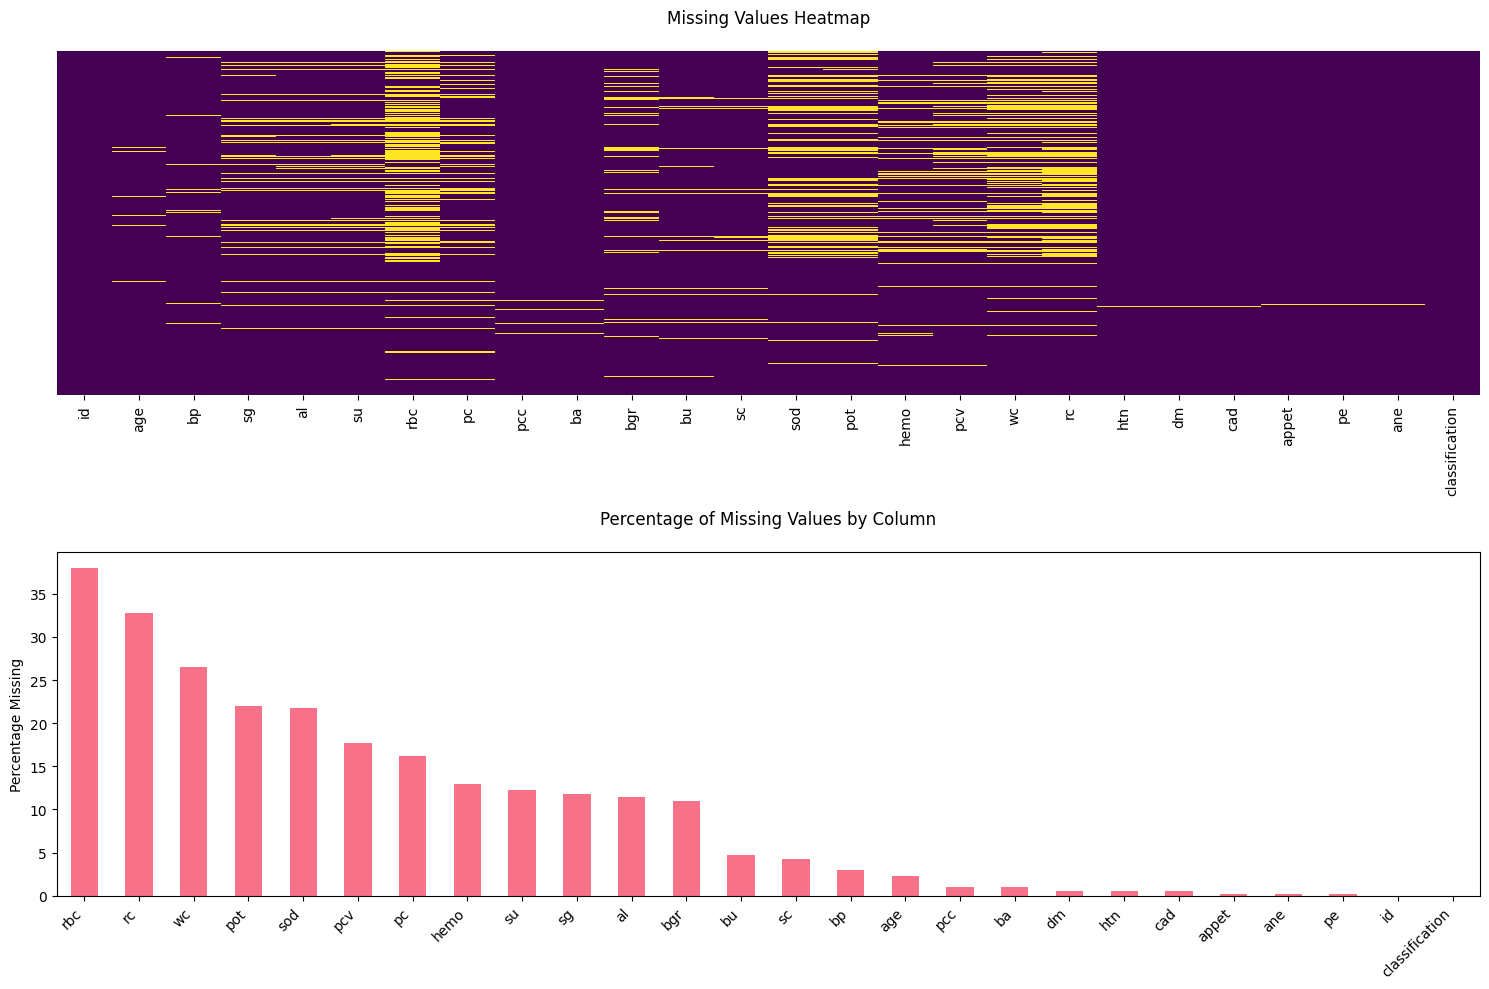


Detailed Missing Value Statistics:
--------------------------------------------------
id:
  Missing values: 0 (0.00%)
  Mean: 199.50
  Median: 199.50
--------------------------------------------------
age:
  Missing values: 9 (2.25%)
  Mean: 51.48
  Median: 55.00
--------------------------------------------------
bp:
  Missing values: 12 (3.00%)
  Mean: 76.47
  Median: 80.00
--------------------------------------------------
sg:
  Missing values: 47 (11.75%)
  Mean: 1.02
  Median: 1.02
--------------------------------------------------
al:
  Missing values: 46 (11.50%)
  Mean: 1.02
  Median: 0.00
--------------------------------------------------
su:
  Missing values: 49 (12.25%)
  Mean: 0.45
  Median: 0.00
--------------------------------------------------
rbc:
  Missing values: 152 (38.00%)
  Most common value: normal
--------------------------------------------------
pc:
  Missing values: 65 (16.25%)
  Most common value: normal
--------------------------------------------------
pcc

In [16]:
plot_missing_heatmap(df_clean)

### Inference: [Visually Dense/Populated]
1. rbc
2. sod, pot (related nulls)
3. wc,rc
4. wc
5. pcv
6. sg,al,su,rbc,pc
7. bgr
8. bp
9. age

### Percentage missing values
- \>30% [CRITICAL]
[rbc,rc]
might need special handling or consideration for dropping

- 5-30% [MODERATE]
[sg,al,su,pc,bgr,sod,pt,hemo,pcv,wc]

- <5% [MINOR]
[id, age, bp, pcc, ba, bu, sc, htn, dm, cad, appet, pe, ane, classification]
simple imputation

## Analyzing Missing Value Patterns

In [17]:
def analyze_missing_patterns(df):
    # Create a correlation matrix of missing values
    missing_corr = df.isnull().corr()

    plt.figure(figsize=(15, 12))  # Increased figure size
    sns.heatmap(missing_corr,
                annot=True,
                cmap='coolwarm',
                center=0,
                annot_kws={'size': 8},  # Smaller annotation font
                fmt='.2f')  # Format to 2 decimal places

    plt.title('Correlation of Missing Values Between Columns', pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=8)  # Rotated and smaller x-tick labels
    plt.yticks(fontsize=8)  # Smaller y-tick labels
    plt.tight_layout()
    plt.show()

    # Analyze if missing values are related to the target variable
    if 'classification' in df.columns:
        print("\nMissing Values by Target Variable:")
        print("-" * 70)  # Wider separator
        for col in df.columns:
            if df[col].isnull().any():
                missing_by_target = df.groupby('classification')[col].apply(lambda x: x.isnull().mean())
                print(f"\n{col:15}")  # Fixed width for column names
                print("-" * 30)
                for target, value in missing_by_target.items():
                    print(f"{target:10}: {value:.2%}")  # Format as percentage
                print("-" * 70)

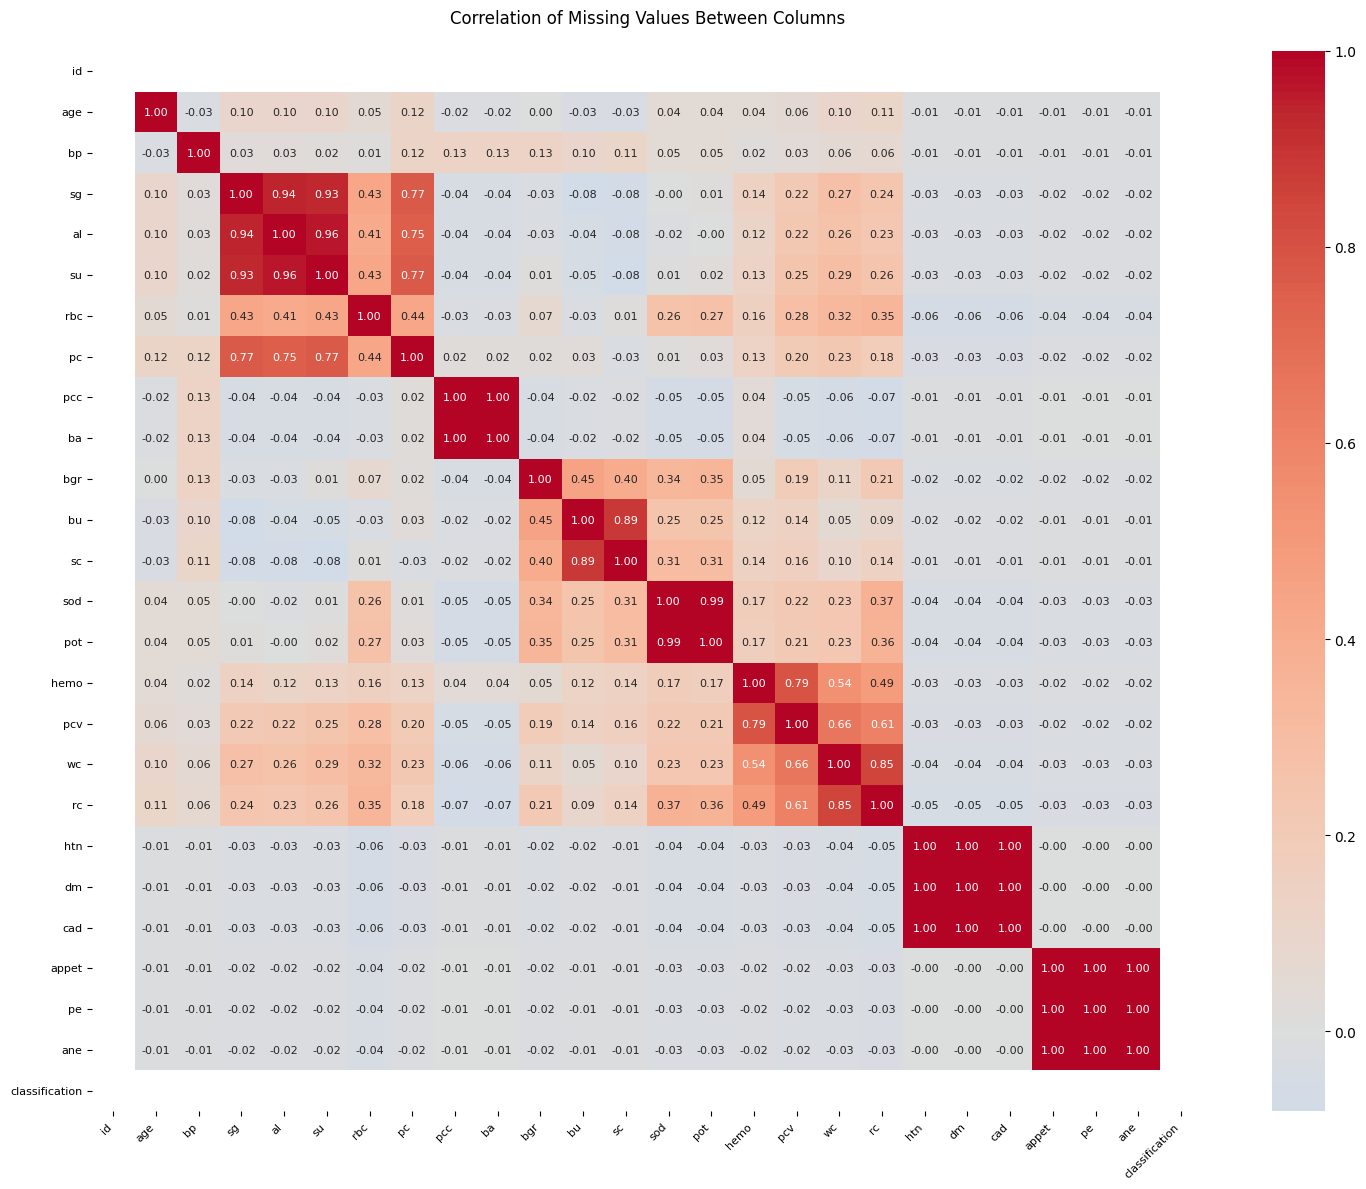


Missing Values by Target Variable:
----------------------------------------------------------------------

age            
------------------------------
ckd       : 3.20%
notckd    : 0.67%
----------------------------------------------------------------------

bp             
------------------------------
ckd       : 4.00%
notckd    : 1.33%
----------------------------------------------------------------------

sg             
------------------------------
ckd       : 16.80%
notckd    : 3.33%
----------------------------------------------------------------------

al             
------------------------------
ckd       : 16.40%
notckd    : 3.33%
----------------------------------------------------------------------

su             
------------------------------
ckd       : 17.60%
notckd    : 3.33%
----------------------------------------------------------------------

rbc            
------------------------------
ckd       : 57.20%
notckd    : 6.00%
------------------------------

In [18]:
analyze_missing_patterns(df_clean)

### **Missing Values Correlation Heatmap Analysis**

- Strong positive correlations (values close to 1): Indicates columns that tend to be missing together (darker shades of red)
- Strong negative correlations (values close to -1): Indicates columns that tend to be present when others are missing (darker shades of blue (ABSENT))
- Values close to 0: Indicates independent missing patterns

- SP: [{appet,pe,ane}, {htn,dm,cad}, {pcc,ba}, {sod,pot}, {sg,al,su}, {bu,sc}, {wc,rc}, {hemo,pcv}, {hemo,pcv,wc,rc}, {sg,al,su,rbc,pc}]
- ModerateP: [{bgr,bu,sc,sod,pot}, {sod,pot,hemo,pcv,wc,rc}]
- WP: [{sg,al,su,rbc,pc}, {hemo,pcv,wc,rc}]

---

### Detailed Analysis With Medical Significance:

#### **Strong Positive Groups (SP)**
- **{appet, pe, ane}:** All are symptoms or clinical findings. If one is missing, likely the others weren’t recorded either—possibly due to incomplete clinical assessment.
- **{htn, dm, cad}:** All are comorbidities. If one is missing, the others are likely missing—possibly due to missing medical history.
- **{pcc, ba}:** Both are urine infection markers, often tested together.
- **{sod, pot}:** Both are electrolytes, always measured together in a metabolic panel.
- **{sg, al, su}:** All are urine test parameters, part of the same urinalysis.
- **{bu, sc}:** Both are kidney function markers, always ordered together.
- **{wc, rc}:** Both are blood cell counts, part of a CBC.
- **{hemo, pcv}:** Both are red cell measures, part of a CBC.
- **{hemo, pcv, wc, rc}:** All are CBC parameters.
- **{sg, al, su, rbc, pc}:** All are urinalysis parameters.

**_Medical Significance:_**  
These patterns reflect real-world clinical practice: tests are often ordered in panels, and if one is missing, the whole panel is likely missing. This is a sign of good data integrity.

---

#### **Moderate/Weak Positive Groups (MP/WP)**
- These show partial overlap, likely due to some tests being ordered together only in certain clinical scenarios (e.g., severe cases, follow-up visits).

## Handling Missing Values
- Low Missing (<5%):
  - Categorical - Filled with mode
  - Numerical - Filled with mean
- Too Many (>30%):
  - Categorical - Make separate category called missing
  - Numerical - None found
- Intermediate Amount (5-30%):
    - Mice Imputer using default imputer model

### Low Missing Values

In [19]:
df_clean['age'].fillna(df_clean['age'].mean(), inplace=True)
df_clean['bp'].fillna(df_clean['bp'].mean(), inplace=True)

In [20]:
low_missing_cats = ['pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
for col in low_missing_cats:
    mode_val = df_clean[col].mode()[0]
    df_clean[col].fillna(mode_val, inplace=True)

### High Missing Values

In [21]:
df_clean['rbc'] = df_clean['rbc'].fillna('missing')
df_clean['pc'] = df_clean['pc'].fillna('missing')

### Intermediate Missing Values

Mice Imputer was chosen because it can impute columns together if they tend to be missing together as observed earlier through the missing value heatmap and correlation matrix based on patterns in the data, instead of imputing randomly
  - Relevant for medical data
  - Ensures integrity is maintained

In [22]:
def mice_impute_group(df, columns, estimator=None, max_iter=10, random_state=0):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[columns])
    imputer = IterativeImputer(estimator=estimator, max_iter=max_iter, random_state=random_state)
    imputed = imputer.fit_transform(scaled)
    df[columns] = scaler.inverse_transform(imputed)
    return df

In [23]:
df_clean = mice_impute_group(df_clean, ['sod', 'pot'])
df_clean = mice_impute_group(df_clean, ['sg', 'al', 'su'])
df_clean = mice_impute_group(df_clean, ['hemo', 'pcv', 'wc', 'rc'])
df_clean = mice_impute_group(df_clean, ['bu', 'sc', 'bgr'])  # bgr included for completeness

### Final Check

In [24]:
print(df_clean.isnull().sum())

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64


### 'al' and 'su' Are Categorical Columns With Oridinal Categories From 0-5

In [25]:
for col in ['al', 'su']:
    df_clean[col] = df_clean[col].round().astype(int)
    df_clean[col] = df_clean[col].clip(lower=0, upper=5)

In [26]:
# Convert to categorical with ordered categories
df_clean['al'] = pd.Categorical(df_clean['al'], categories=[0,1,2,3,4,5], ordered=True)
df_clean['su'] = pd.Categorical(df_clean['su'], categories=[0,1,2,3,4,5], ordered=True)

### Converting Object to Category

In [ ]:
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].astype('category')

# Outlier Analysis and Removal

## Numerical Columns

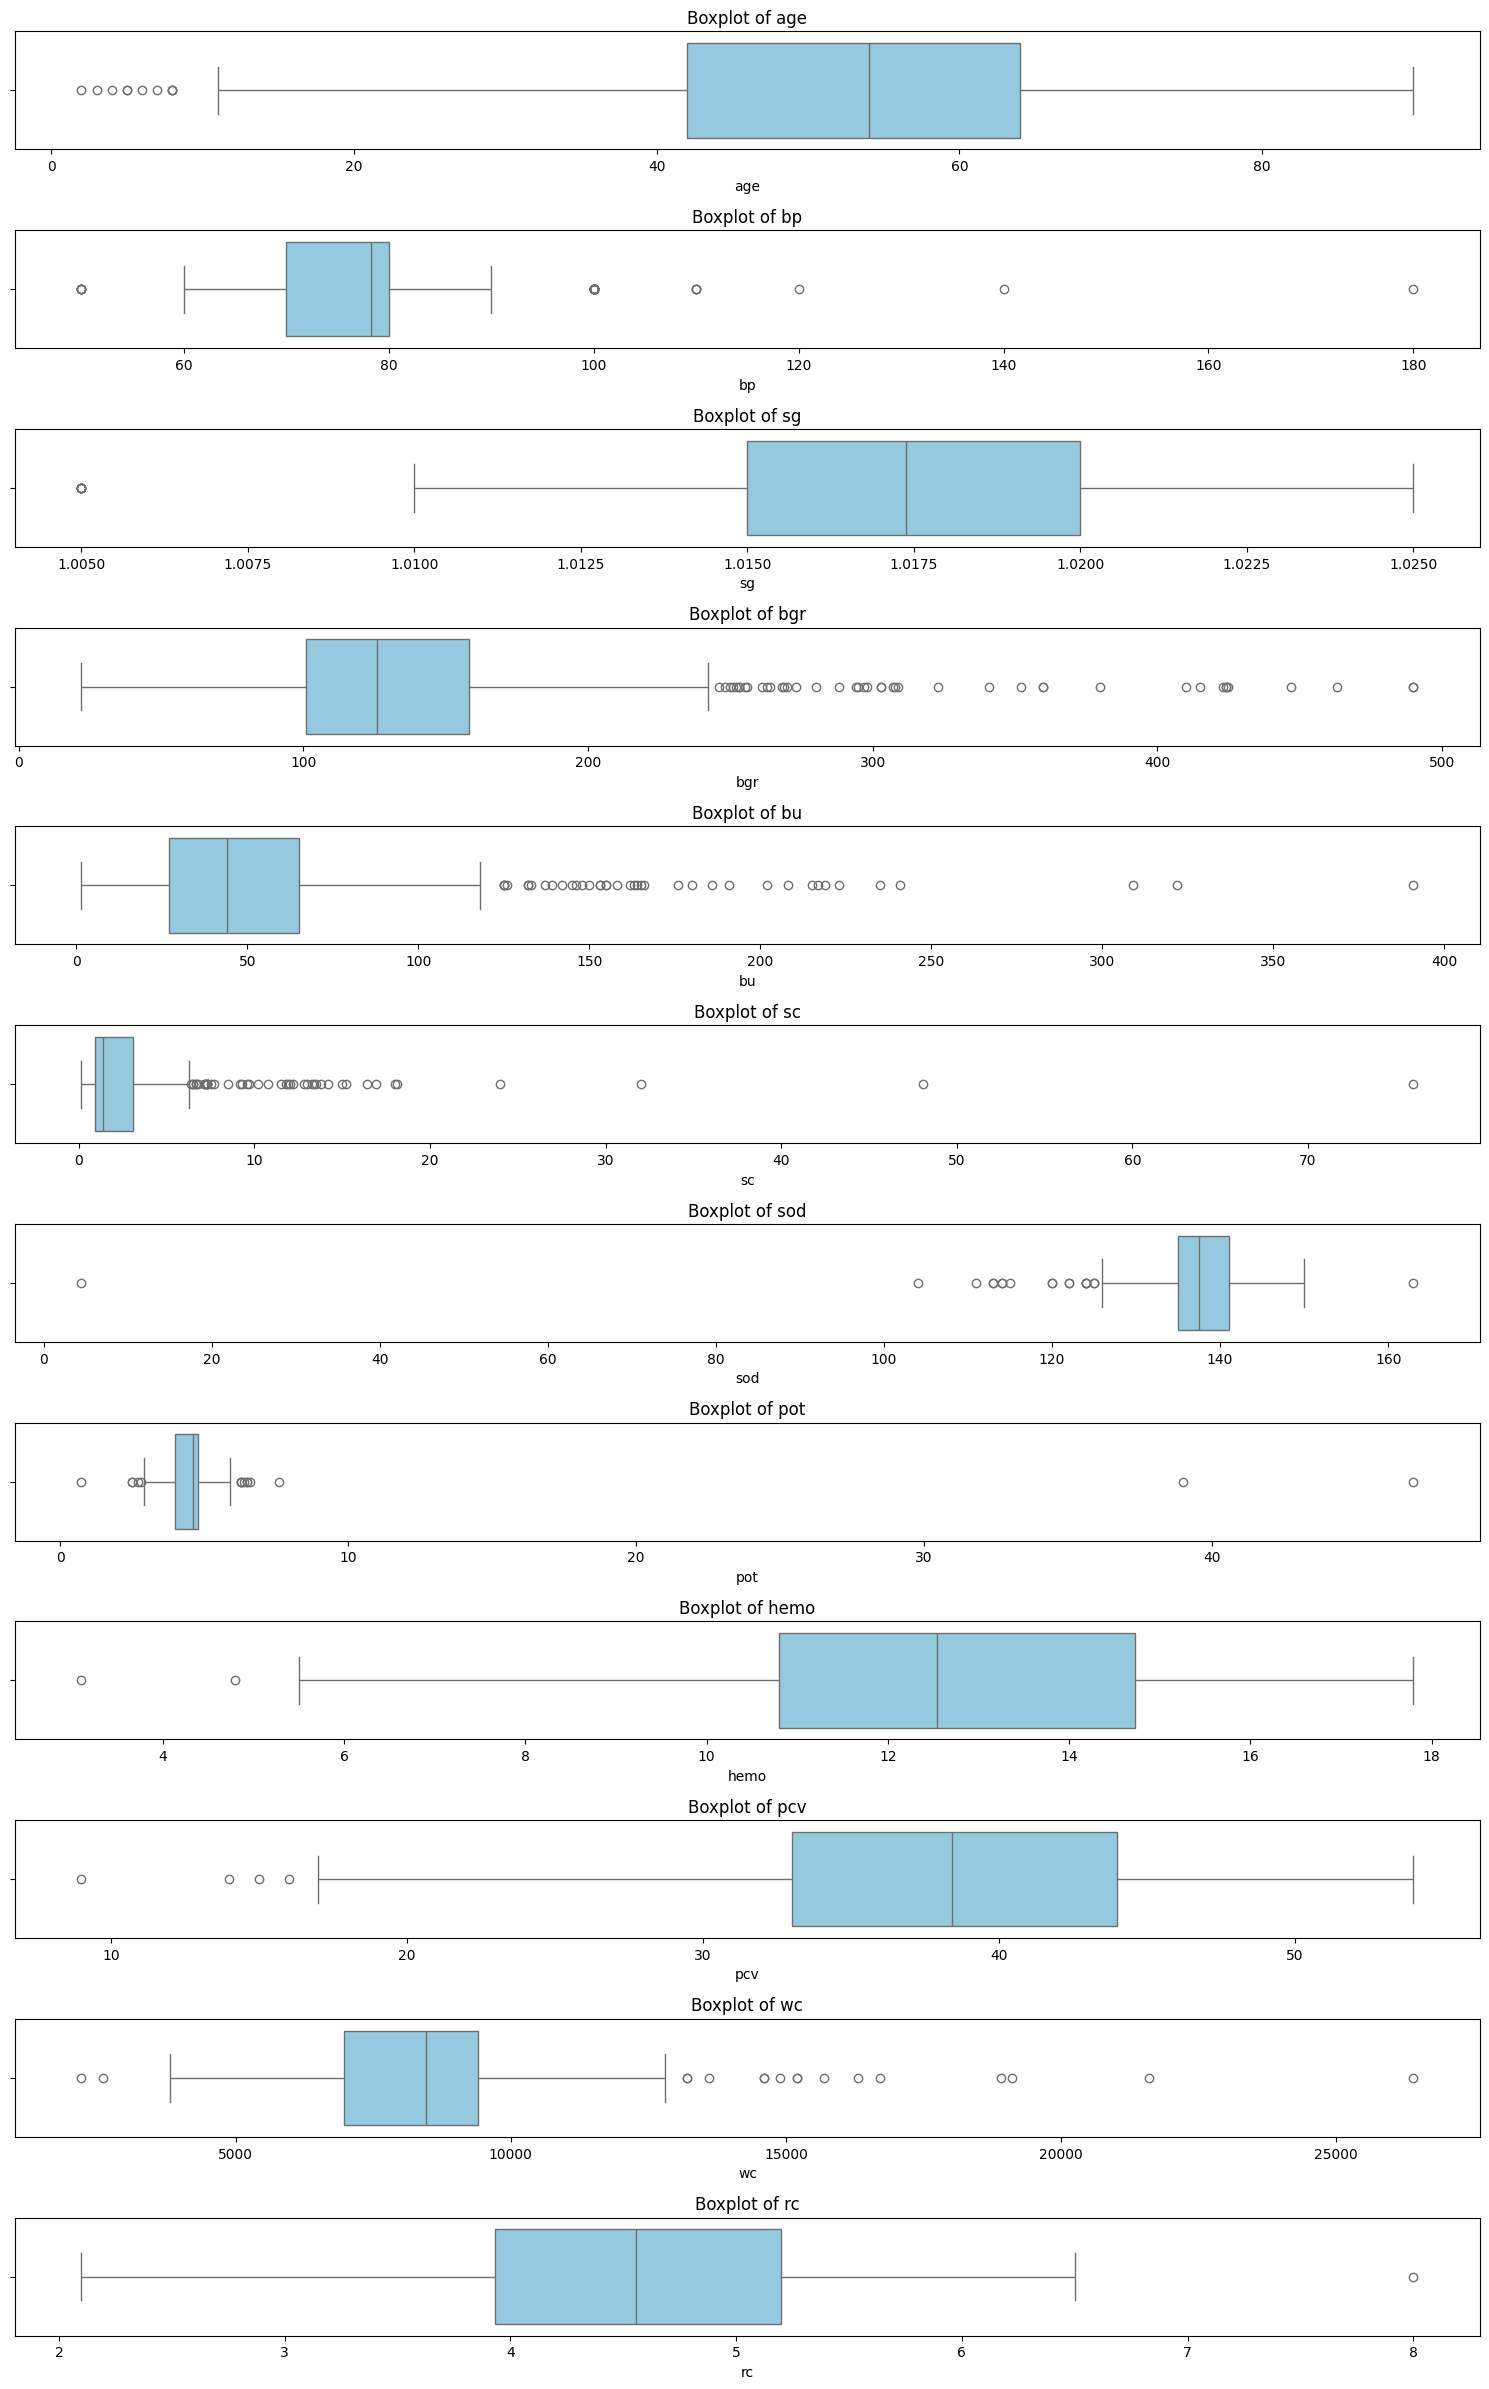

In [28]:
numerical_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['id']]  # Exclude id

plt.figure(figsize=(15, 2 * len(numerical_cols)))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols), 1, i)
    sns.boxplot(x=df_clean[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
plt.show()

### Number of  Outliers

In [29]:
outlier_summary = {}
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)][col]
    outlier_summary[col] = {
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'num_outliers': outliers.count(),
        'outlier_values': outliers.values
    }
    print(f"{col}: {outliers.count()} outliers")

age: 10 outliers
bp: 36 outliers
sg: 7 outliers
bgr: 43 outliers
bu: 39 outliers
sc: 44 outliers
sod: 18 outliers
pot: 15 outliers
hemo: 2 outliers
pcv: 4 outliers
wc: 17 outliers
rc: 1 outliers


### Outlier Summary to Take Further Action

In [30]:
for col in outlier_summary:
    print(f"{col}: {outlier_summary[col]['num_outliers']} outliers")
    print(f"Lower Bound: {outlier_summary[col]['lower_bound']}")
    print(f"Upper Bound: {outlier_summary[col]['upper_bound']}")
    print(f"Outlier Values: {outlier_summary[col]['outlier_values']}")
    print("--------------------------------")

age: 10 outliers
Lower Bound: 9.0
Upper Bound: 97.0
Outlier Values: [7. 5. 5. 8. 4. 8. 3. 8. 6. 2.]
--------------------------------
bp: 36 outliers
Lower Bound: 55.0
Upper Bound: 95.0
Outlier Values: [ 50. 100. 100. 100. 100. 100. 100. 100. 100. 100. 110. 100. 100. 140.
 180. 100. 100.  50. 100. 100. 100.  50.  50. 110. 100. 100. 100. 120.
 100. 100.  50. 100. 100. 100. 100. 110.]
--------------------------------
sg: 7 outliers
Lower Bound: 1.0074999999999998
Upper Bound: 1.0275000000000003
Outlier Values: [1.005 1.005 1.005 1.005 1.005 1.005 1.005]
--------------------------------
bgr: 43 outliers
Lower Bound: 15.5
Upper Bound: 243.5
Outlier Values: [423. 410. 490. 380. 263. 264. 270. 246. 253. 425. 250. 360. 360. 415.
 251. 280. 295. 298. 297. 294. 323. 308. 268. 256. 288. 273. 424. 303.
 307. 447. 309. 261. 352. 252. 341. 255. 253. 248. 303. 490. 269. 463.
 424.]
--------------------------------
bu: 39 outliers
Lower Bound: -30.374999999999996
Upper Bound: 122.625
Outlier Values: [

### Removing The Outliers

In [31]:
# Count before removal
removed_sod = np.sum(np.isclose(df_clean['sod'], 4.5, atol=0.01))
removed_pot = np.sum(df_clean['pot'] >= 39)
removed_pcv = np.sum(np.isclose(df_clean['pcv'], 9.0, atol=0.01))

print(f"Rows to be removed for sod: {removed_sod}")
print(f"Rows to be removed for pot: {removed_pot}")
print(f"Rows to be removed for pcv: {removed_pcv}")

Rows to be removed for sod: 1
Rows to be removed for pot: 2
Rows to be removed for pcv: 1


In [32]:
# Now remove the impossible values
df_clean = df_clean[~np.isclose(df_clean['sod'], 4.5, atol=0.01) | df_clean['sod'].isnull()]
df_clean = df_clean[(df_clean['pot'].isnull()) | (df_clean['pot'] < 39)]
df_clean = df_clean[~np.isclose(df_clean['pcv'], 9.0, atol=0.01)]

> ### Outlier Handling Documentation
>
> We checked all the medical data ranges for all these numerical columns for which box plots were made and decided to remove only those that were clinically impossible. Other outliers were possible, but as a result of severe disease. Since the other records provided valuable medical information, we decided to keep them.
> - **sod (Sodium):**  
>   - Removed rows where sod = 4.5 mEq/L (physiologically impossible).  
>   - Retained all other values, including extreme hyponatremia/hypernatremia, as these are possible in severe kidney disease.
>
> - **pot (Potassium):**  
>   - Removed rows where pot ≥ 39 mmol/L (clinically impossible).  
>   - Retained all other values, including severe hypo/hyperkalemia, as these are possible in advanced disease.
>
> - **pcv (Packed Cell Volume):**  
>   - Removed rows where pcv = 9% (clinically impossible).  
>   - Retained all other values, including severe anemia, as these are possible in advanced disease.
>
> - **All other columns:**  
>   - Retained all outlier values, as they are medically possible, though some are rare or dangerous. This preserves the clinical diversity of the dataset for robust modeling.


# Save the dataset

In [33]:
# Removing 'id' (Not useful for pattern finding)
if 'id' in df_clean.columns:
    df_clean = df_clean.drop(columns=['id'])

In [34]:
df_clean.to_csv("Dataset/df_clean.csv", index=False)